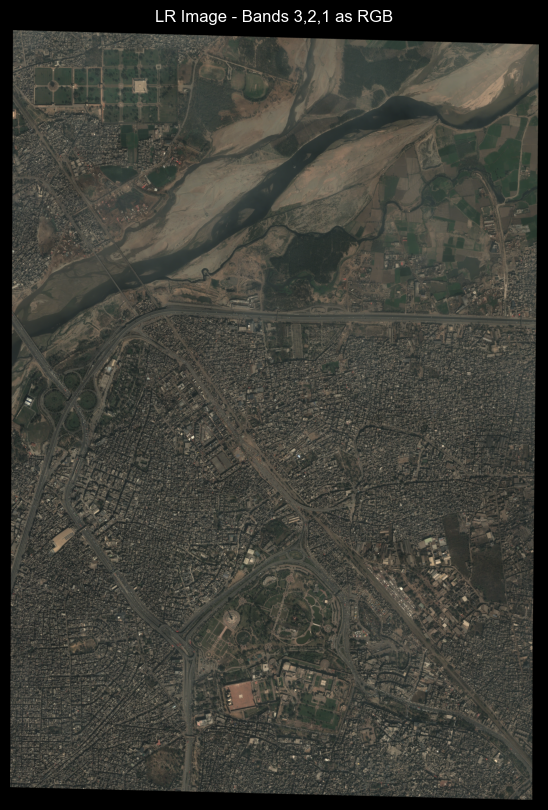

In [7]:
import rasterio
import matplotlib.pyplot as plt
import numpy as np

# Path from pipeline.py
lr_path = "Lahore/LR/IMG_PHR1A_PMS_001/IMG_PHR1A_PMS_202602130556014_ORT_38a71b19-2781-4146-c1f3-561512adaf94_R1C1.JP2"
# Note: In the terminal, the path was absolute. Assuming relative to the notebook's parent directory if running from there.
# Let's use the full path to be safe, or just the relative one if we are in the right place.
# Based on workspace info, the file is in pleaide_preprocessing/
full_lr_path = "/Users/Hassaan/PycharmProjects/KAIR/pleaides_preprocessing/" + lr_path

# Pleiades 1A: Red=3, Green=2, Blue=1
# User wants bands 123 in reverse order as RGB (which is 3, 2, 1)
bands = [1,2,3]

with rasterio.open(full_lr_path) as src:
    data = src.read(bands) # (3, H, W)
    # Convert to float and divide by a constant (e.g., 2047 or 4095 for 11/12 bit, or 32767 for max uint16)
    # Satellite imagery often has a specific bit depth. 2000-4000 is common for display.
    # Let's use 4095 as a "suitable constant" for many sensors, or max of data.
    display_data = data.astype(np.float32) / 4000.0
    display_data = np.clip(display_data, 0, 1)

    # Transpose to (H, W, 3) for matplotlib
    display_data = np.transpose(display_data, (1, 2, 0))

plt.figure(figsize=(10, 10))
plt.imshow(display_data)
plt.title("LR Image - Bands 3,2,1 as RGB")
plt.axis('off')
plt.show()


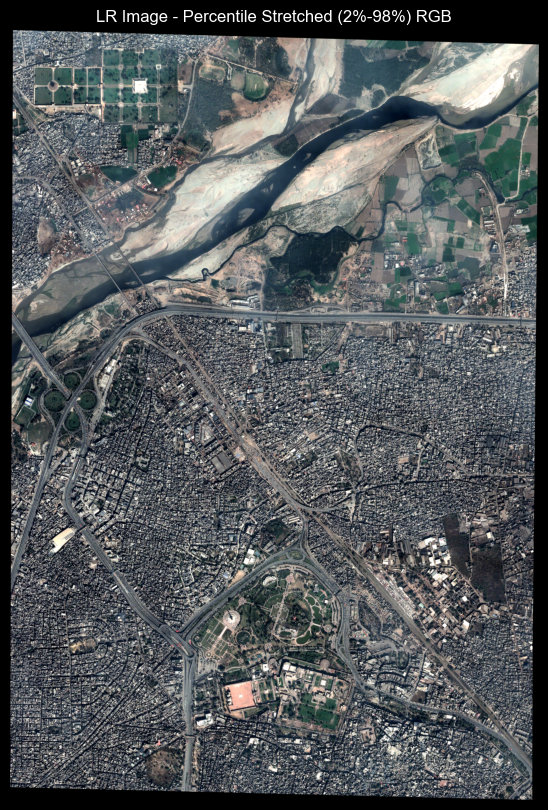

In [8]:
# Section: Percentile Scaling and Min-Max Stretch
# Following the logic from pipeline.py's scale_to_uint8 but for display

def stretch_image(data, p_lo=2, p_hi=98):
    stretched_bands = []
    for i in range(data.shape[0]):
        band = data[i].astype(np.float32)

        # 1. Percentile Scaling: Find p2 and p98
        v_min, v_max = np.percentile(band[band > 0], [p_lo, p_hi])

        # 2. Clip and Min-Max Stretch to [0, 1]
        clipped = np.clip(band, v_min, v_max)
        normalized = (clipped - v_min) / (v_max - v_min)
        stretched_bands.append(normalized)

    return np.transpose(np.array(stretched_bands), (1, 2, 0))

with rasterio.open(full_lr_path) as src:
    data = src.read(bands)
    stretched_rgb = stretch_image(data)

plt.figure(figsize=(10, 10))
plt.imshow(stretched_rgb)
plt.title(f"LR Image - Percentile Stretched (2%-98%) RGB")
plt.axis('off')
plt.show()
